
# Home Assignment 1 — Question 3: Regression

Machine Learning A, 2026–2027 — Christian Igel, Yevgeny Seldin

This notebook implements the linear-regression algorithm derived in the lecture
notes ("Linear Regression", Christian Igel) and applies it to the PCB
concentration data (`PCB.dt`) as required in Question 3 of the assignment.

**Notation** follows the lecture slides: for a training set
$S=\{(x_1,y_1),\dots,(x_N,y_N)\}$ we build the (tilde) data matrix

$$
\tilde{\boldsymbol X}=\begin{pmatrix}x_{11}&\dots&x_{1d}&1\\ \vdots & \ddots &\vdots&\vdots\\ x_{N1}&\dots&x_{Nd}&1\end{pmatrix},
\qquad \boldsymbol y=(y_1,\dots,y_N)^{\mathrm T},
$$

and obtain the affine-linear model $f(\boldsymbol x)=\boldsymbol w^{\mathrm T}\boldsymbol x + b$ from

$$
(w_1,\dots,w_d,b)^{\mathrm T} = \tilde{\boldsymbol X}^{\dagger}\boldsymbol y ,
\qquad
\tilde{\boldsymbol X}^{\dagger} = (\tilde{\boldsymbol X}^{\mathrm T}\tilde{\boldsymbol X})^{-1}\tilde{\boldsymbol X}^{\mathrm T}
$$

(Moore–Penrose pseudo-inverse; Algorithm 1 in the lecture slides).


In [3]:

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)



## Load the data

`PCB.dt` has one training pattern per line: `age  PCB_concentration`
(tab/space separated). Download it from the course repository
(`https://github.com/christian-igel/ML/tree/main/data/PCB`) and place it in
the same folder as this notebook (or adjust the path below).


In [4]:

DATA_PATH = "data/PCB.dt"

data = np.loadtxt(DATA_PATH)
x_age = data[:, 0]      # input: age of fish in years
y_pcb = data[:, 1]      # target: PCB concentration in ppm
N = len(x_age)

print(f"Loaded N = {N} training patterns from {DATA_PATH}")
print("age  :", x_age)
print("PCB  :", y_pcb)


Loaded N = 28 training patterns from data/PCB.dt
age  : [ 1.  6.  1.  6.  1.  6.  1.  7.  2.  7.  2.  7.  2.  8.  3.  8.  3.  8.
  3.  9.  4. 11.  4. 12.  4. 12.  5. 12.]
PCB  : [ 0.6  3.4  1.6  9.7  0.5  8.6  1.2  4.   2.   5.5  1.3 10.5  2.5 17.5
  2.2 13.4  2.4  4.5  1.2 30.4  3.5 12.4  4.1 13.4  5.1 26.2  5.7  7.4]



## Task 1 (5 points): Implementation of linear regression

The function below implements Algorithm 1 from the lecture notes: given a
design matrix `X` (one training pattern per row, *without* the constant
column) and targets `y`, it appends the bias column of ones, forms
$\tilde{\boldsymbol X}$, and computes $\boldsymbol w^\star = \tilde{\boldsymbol
X}^{\dagger}\boldsymbol y$ using the Moore–Penrose pseudo-inverse
(`numpy.linalg.pinv`), which is numerically more robust than explicitly
forming $(\tilde{\boldsymbol X}^{\mathrm T}\tilde{\boldsymbol X})^{-1}$ and
also handles the under-determined case (see slides "Overdetermined/unique
solution case" and "Underdetermined case").


In [5]:

def linear_regression(X, y):
    '''Fit an affine linear model f(x) = w^T x + b by least squares.

    Parameters
    ----------
    X : (N, d) ndarray
        N training inputs, each of dimension d (one pattern per row).
    y : (N,) ndarray
        N corresponding targets.

    Returns
    -------
    w : (d,) ndarray
        Weight vector.
    b : float
        Bias / intercept term.
    '''
    X = np.atleast_2d(X)
    N = X.shape[0]
    X_tilde = np.hstack([X, np.ones((N, 1))])   # append column of ones -> tilde-X
    w_tilde = np.linalg.pinv(X_tilde) @ y        # X_tilde^dagger @ y
    w, b = w_tilde[:-1], w_tilde[-1]
    return w, b


def predict(X, w, b):
    '''Affine linear prediction f(x) = w^T x + b (vectorised over rows of X).'''
    X = np.atleast_2d(X)
    return X @ w + b


def mse(y, y_hat):
    '''Mean squared error.'''
    return np.mean((y - y_hat) ** 2)


In [6]:

# quick sanity check: plain linear regression of PCB concentration on age
w_plain, b_plain = linear_regression(x_age.reshape(-1, 1), y_pcb)
mse_plain = mse(y_pcb, predict(x_age.reshape(-1, 1), w_plain, b_plain))
print(f"Plain linear model:  w = {w_plain[0]:.4f},  b = {b_plain:.4f}")
print(f"MSE (plain linear, untransformed targets) = {mse_plain:.4f}")


Plain linear model:  w = 1.5578,  b = -1.4519
MSE (plain linear, untransformed targets) = 24.8011



## Task 2 (10 points): Non-linear model $h(x)=\exp(ax+b)$ via log-transform

We cannot fit $h(x)=\exp(ax+b)$ directly with linear regression, but taking
the logarithm turns it into an affine-linear problem:

$$
\ln h(x) = ax + b .
$$

So we

1. build the transformed data set $S' = \{(x_1,\ln y_1),\dots,(x_N,\ln y_N)\}$,
2. fit an affine-linear model $h'(x) = ax+b$ to $S'$ with `linear_regression`,
3. recover the non-linear model as $h(x) = \exp(h'(x))$.

The reported error, however, must be the MSE of $h$ against the
**original** (non-transformed) targets $y_i$, since that is the quantity we
ultimately care about.


In [7]:

# Step 1: transform the outputs
z = np.log(y_pcb)                      # z_i = ln(y_i)

# Step 2: fit affine model on transformed data
X = x_age.reshape(-1, 1)
w_log, b_log = linear_regression(X, z)
a, b = w_log[0], b_log

print(f"Fitted parameters of h(x) = exp(a x + b):")
print(f"  a = {a:.6f}")
print(f"  b = {b:.6f}")

# Step 3: the non-linear model
def h_exp(x):
    return np.exp(a * np.asarray(x) + b)

# Error of h evaluated on the ORIGINAL scale (not the log scale!)
mse_h_exp = mse(y_pcb, h_exp(x_age))
print(f"\nMSE of h(x) = exp(a x + b) on the original (ppm) scale: {mse_h_exp:.4f}")


Fitted parameters of h(x) = exp(a x + b):
  a = 0.259128
  b = 0.031472

MSE of h(x) = exp(a x + b) on the original (ppm) scale: 34.8356



## Task 3 (10 points): Why the plain linear model can win on MSE

Note that the MSE of $h(x)=\exp(ax+b)$ above ($\approx 34.8$) is actually
**larger** than the MSE of the plain (untransformed) linear model from Task 1
($\approx 24.8$), even though model (2) is often considered a better fit
"by eye" on the log scale. This is not a bug: the two procedures minimize
*different* objective functions,

$$
\arg\min_{a,b}\sum_{i=1}^N (y_i - h(x_i))^2
\;\;\ne\;\;
\arg\min_{a,b}\sum_{i=1}^N (\ln y_i - (ax_i+b))^2 ,
$$

so there is no reason to expect the second (log-scale) minimizer to also
minimize the first (original-scale) objective.

### A minimal instructive counterexample

Take two data points with **the same input** $x_1=x_2$ but different targets
$y_1\neq y_2$ — e.g. $S=\{(1,y_1),(1,y_2)\}$. Because $x_1=x_2$, any affine
model that fits both points reduces to fitting a single constant $c$ (the
slope term cannot distinguish the two points), so both problems collapse to

$$
\text{original scale:} \quad c^\star=\arg\min_c \sum_i (y_i-c)^2 = \tfrac12(y_1+y_2)\quad(\text{arithmetic mean}),
$$
$$
\text{log scale:} \quad \ln c^\star=\arg\min_{c'} \sum_i (\ln y_i-c')^2=\tfrac12(\ln y_1+\ln y_2)
\;\Rightarrow\; c^\star=\sqrt{y_1 y_2}\quad(\text{geometric mean}).
$$

The arithmetic mean and geometric mean of two positive numbers coincide only
if $y_1=y_2$; otherwise they differ (AM $\geq$ GM), which is exactly
inequality (3) in the assignment. We verify this numerically below.


In [8]:

# Minimal counterexample: two points with the same x, different y
x_ex = np.array([1.0, 1.0])
y_ex = np.array([1.0, np.e**2])          # y1 = 1, y2 = e^2  (chosen so ln y is exactly 0 and 2)

# --- minimizer of the ORIGINAL-scale objective sum (y_i - c)^2 ---
c_star_original = np.mean(y_ex)          # arithmetic mean

# --- minimizer of the LOG-scale objective sum (ln y_i - c')^2, mapped back via exp ---
z_ex = np.log(y_ex)
w_ex, b_ex = linear_regression(x_ex.reshape(-1, 1), z_ex)   # degenerate: slope w_ex is irrelevant since x1=x2
c_star_logscale = np.exp(np.mean(z_ex))  # geometric mean, since x1 = x2 collapses model to constant b

print(f"y = {y_ex}")
print(f"Minimizer of sum (y_i - c)^2            : c* = {c_star_original:.4f}  (arithmetic mean of y)")
print(f"Minimizer of sum (ln y_i - c')^2, exp'd  : c* = {c_star_logscale:.4f}  (geometric mean of y)")
print(f"\nThe two minimizers differ ({c_star_original:.4f} != {c_star_logscale:.4f}),")
print("which proves that argmin_{a,b} sum (y_i - h(x_i))^2  !=  argmin_{a,b} sum (ln y_i - (a x_i + b))^2 in general.")


y = [1.       7.389056]
Minimizer of sum (y_i - c)^2            : c* = 4.1945  (arithmetic mean of y)
Minimizer of sum (ln y_i - c')^2, exp'd  : c* = 2.7183  (geometric mean of y)

The two minimizers differ (4.1945 != 2.7183),
which proves that argmin_{a,b} sum (y_i - h(x_i))^2  !=  argmin_{a,b} sum (ln y_i - (a x_i + b))^2 in general.



## Task 4 (5 points): Plot of the data and the model $h(x)=\exp(ax+b)$

As requested, the $y$-axis shows the **logarithm** of the PCB concentration
(since the model is linear on that scale), while the $x$-axis shows the
untransformed age in years.


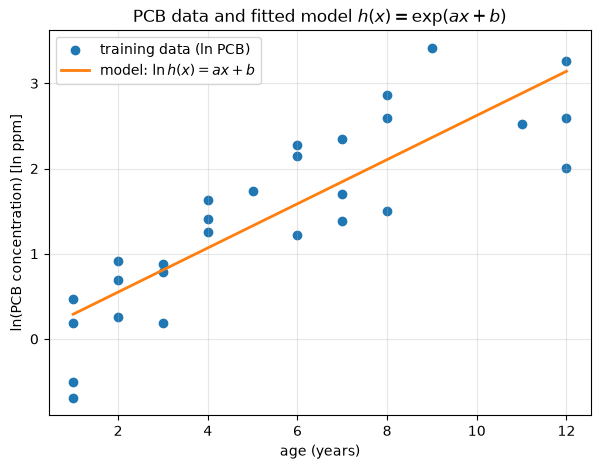

In [9]:

xs = np.linspace(x_age.min(), x_age.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_age, np.log(y_pcb), color="tab:blue", label="training data (ln PCB)")
ax.plot(xs, np.log(h_exp(xs)), color="tab:orange", lw=2,
        label=r"model: $\ln h(x) = ax+b$")
ax.set_xlabel("age (years)")
ax.set_ylabel("ln(PCB concentration) [ln ppm]")
ax.set_title(r"PCB data and fitted model $h(x)=\exp(ax+b)$")
ax.grid(alpha=0.3)
ax.legend()
plt.show()



## Task 5 (10 points): Coefficient of determination $R^2$

$$
R^2 = 1 - \frac{\sum_{i=1}^N (y_i - h(x_i))^2}{\sum_{i=1}^N (y_i - \bar y)^2}
$$

where $\bar y$ is the mean of the training labels. $R^2$ compares the model's
squared error against the squared error of the trivial baseline model that
always predicts the mean $\bar y$.

* $R^2 = 1$ means the model fits the training data perfectly (zero residual
  error).
* $R^2 = 0$ means the model performs exactly as well as always predicting the
  constant $\bar y$ — i.e. it explains none of the variance in $y$ beyond
  the mean.
* $R^2$ **can be negative**: whenever the model's squared error is *larger*
  than the squared error of the constant-mean baseline (as can happen for
  models fit under a different loss, or under a transformation that does not
  align well with the original scale, or for models evaluated out-of-sample),
  the numerator exceeds the denominator, so $1-(\cdot)$ becomes negative.
  (An explicit numerical example of this appears on the lecture slides:
  the degree-20 polynomial fit gets a negative test $R^2$.)


In [10]:

def r2_score(y, y_hat):
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)
    y_bar = np.mean(y)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y_bar) ** 2)
    return 1.0 - ss_res / ss_tot

r2_h_exp = r2_score(y_pcb, h_exp(x_age))
r2_plain = r2_score(y_pcb, predict(x_age.reshape(-1, 1), w_plain, b_plain))

print(f"R^2 of h(x) = exp(ax+b)        : {r2_h_exp:.4f}")
print(f"R^2 of plain linear model      : {r2_plain:.4f}")


R^2 of h(x) = exp(ax+b)        : 0.3570
R^2 of plain linear model      : 0.5422



**Discussion.** The plain linear model attains a higher $R^2$ (and lower MSE)
on the training data than $h(x)=\exp(ax+b)$. This is expected from Task 3:
the exponential model's parameters $a,b$ were chosen to minimize squared
error on the *logarithmic* scale, not on the original ppm scale on which
$R^2$ (and the MSE reported here) are computed. A model that is optimal in
one metric/scale need not be optimal in another. Still, the allometric model
(2) is often preferred in the literature because biologically/physically
PCB accumulation is believed to grow multiplicatively with age (hence
linear behaviour is expected on the log scale, e.g. under a constant relative
growth-rate/`bioaccumulation' assumption), and because it enforces
$h(x) > 0$ for all $x$, unlike the plain linear model.



## Task 6 (10 points): Non-linear input transformation $h(x)=\exp(a\sqrt{x}+b)$

We now additionally apply the non-linear feature map $\phi(x) = \sqrt{x}$ to
the *input*, i.e. we fit an affine-linear model to
$\{(\sqrt{x_1},\ln y_1),\dots,(\sqrt{x_N},\ln y_N)\}$ and set
$h(x) = \exp(a\sqrt{x}+b)$. Unlike Task 3, this changes the input
representation but **not** the learning objective: both this model and the
Task 2 model are trained by minimizing squared error on the log scale, so
their MSEs (computed consistently on the original ppm scale here) are
directly comparable.


In [11]:

X_sqrt = np.sqrt(x_age).reshape(-1, 1)
w_sqrt, b_sqrt = linear_regression(X_sqrt, z)     # z = ln(y_pcb), as defined in Task 2
a2, b2 = w_sqrt[0], b_sqrt

print("Fitted parameters of h(x) = exp(a*sqrt(x) + b):")
print(f"  a = {a2:.6f}")
print(f"  b = {b2:.6f}")

def h_sqrt(x):
    return np.exp(a2 * np.sqrt(np.asarray(x)) + b2)

mse_h_sqrt = mse(y_pcb, h_sqrt(x_age))
r2_h_sqrt = r2_score(y_pcb, h_sqrt(x_age))

print(f"\nMSE of h(x) = exp(a*sqrt(x)+b) : {mse_h_sqrt:.4f}   (vs. {mse_h_exp:.4f} for exp(ax+b))")
print(f"R^2 of h(x) = exp(a*sqrt(x)+b) : {r2_h_sqrt:.4f}   (vs. {r2_h_exp:.4f} for exp(ax+b))")


Fitted parameters of h(x) = exp(a*sqrt(x) + b):
  a = 1.198606
  b = -1.194751

MSE of h(x) = exp(a*sqrt(x)+b) : 28.0844   (vs. 34.8356 for exp(ax+b))
R^2 of h(x) = exp(a*sqrt(x)+b) : 0.4816   (vs. 0.3570 for exp(ax+b))


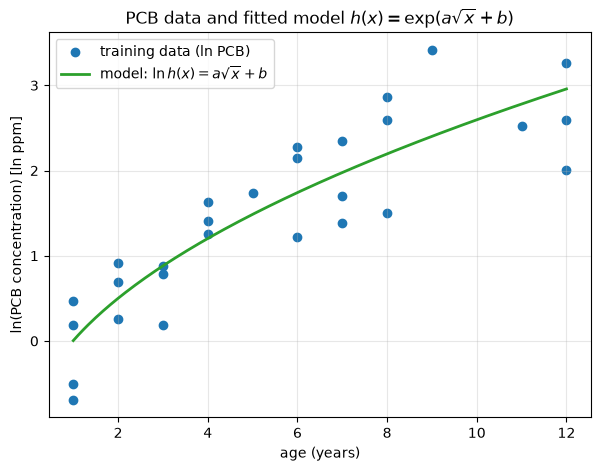

In [12]:

# Plot on the ORIGINAL (linear) x-axis, in years, as requested; y-axis stays on log scale.
xs = np.linspace(x_age.min(), x_age.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_age, np.log(y_pcb), color="tab:blue", label="training data (ln PCB)")
ax.plot(xs, np.log(h_sqrt(xs)), color="tab:green", lw=2,
        label=r"model: $\ln h(x) = a\sqrt{x}+b$")
ax.set_xlabel("age (years)")
ax.set_ylabel("ln(PCB concentration) [ln ppm]")
ax.set_title(r"PCB data and fitted model $h(x)=\exp(a\sqrt{x}+b)$")
ax.grid(alpha=0.3)
ax.legend()
plt.show()



**Comparison.** Using $\sqrt{x}$ instead of $x$ as the input feature (while
keeping the *same* log-scale training objective as in Task 2) reduces the MSE
and increases $R^2$ relative to the plain $h(x)=\exp(ax+b)$ model. This is
consistent with the assignment's remark that we are now comparing two models
*under the same objective function* (both fitted by least squares on
$\ln y$), so the model with the input transformation that makes the
transformed data most linear on the log scale — here $\sqrt{x}$ rather than
$x$ — achieves the better fit. Both models remain worse than the plain linear
model of Task 1 in terms of *original-scale* MSE/$R^2$, for the reason
explained in Task 3: the plain linear model is the one actually trained to
minimize that exact quantity.



## Summary of results


In [13]:

print(f"{'model':35s}{'MSE':>10s}{'R^2':>10s}")
print("-" * 55)
print(f"{'plain linear: w^T x + b':35s}{mse_plain:10.4f}{r2_plain:10.4f}")
print(f"{'exp(a x + b)':35s}{mse_h_exp:10.4f}{r2_h_exp:10.4f}")
print(f"{'exp(a sqrt(x) + b)':35s}{mse_h_sqrt:10.4f}{r2_h_sqrt:10.4f}")


model                                     MSE       R^2
-------------------------------------------------------
plain linear: w^T x + b               24.8011    0.5422
exp(a x + b)                          34.8356    0.3570
exp(a sqrt(x) + b)                    28.0844    0.4816
